# analysis.detection-statistics-virus


## Summary 

In this notebook, we focus on the numbers generated by the previous virus-taxonomic profiling using a BLAST-based pipeline. We read mostly content from the `metadata.site-library.csv` files and from `hits.virus.csv`. 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import taxoniq
from daforfer import DaforferDB
plt.rcParams['svg.fonttype'] = 'none'
from yaml import load, Loader
from daforfer import DaforferDB
conf = load(open("conf.yaml"), Loader)
db = DaforferDB(conf['database'])
db.toc()

┌────────────────────────────────────┬────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│                name                │                                                                                  description                                                                                   │
│              varchar               │                                                                                    varchar                                                                                     │
├────────────────────────────────────┼────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│ D_bacteriaHits                     │ This table contains all the MOTUS hits obtained, regardless of their status. It contains the libr

## Bacteria

We carry out the analysis here by making questions and answering them.

### How many bacteria were detected?

To know that, first we need to load the data. 

In [2]:
virus_hits = db.conn.sql('SELECT * FROM D_virusHits').df()
metadata = db.conn.sql('SELECT * FROM D_sites').df()

In [3]:
virus_hits

,library,acronym,taxid,scientific_name
0,PV001,CMV3,12305,Cucumber mosaic virus RNA 3
1,PV001,CmEV,1776177,Cucumis melo endornavirus
2,PV001,GMMV3,578305,Gayfeather mild mottle virus RNA 3
3,PV001,RuCMV,378833,Rubus chlorotic mottle virus
4,PV002,CMV3,12305,Cucumber mosaic virus RNA 3
...,...,...,...,...
1611,PV589,CYDV_RPV,2170100,Cereal yellow dwarf virus - RPV
1612,PV589,WYDV_GPV,572239,Wheat yellow dwarf virus - GPV
1613,PV590,CMV_satRNA,None,Cucumber mosaic virus satellite RNA
1614,PV590,RuCMV,378833,Rubus chlorotic mottle virus


In [4]:
len(virus_hits.acronym.unique())

158

In [5]:
len(virus_hits.scientific_name.unique())

158

Now, we value count the different taxids. 

In [6]:
virus_hits = pd.merge(metadata, virus_hits, on='library', how='left').dropna(subset='scientific_name')
# virus_hits['taxid'] = virus_hits['taxid'].astype(int)
virus_hits

,site,library,habitat,n_extracts,host_taxon,acronym,taxid,scientific_name
0,C1,PV534,Crop,3,Diplotaxis erucoides,BYDV_GAV,224578,Barley yellow dwarf virus - GAV
1,C1,PV534,Crop,3,Diplotaxis erucoides,BYDV_PAS,2169985,Barley yellow dwarf virus - PAS
2,C1,PV534,Crop,3,Diplotaxis erucoides,BYDV_PAV,2169986,Barley yellow dwarf virus - PAV
3,C1,PV534,Crop,3,Diplotaxis erucoides,CMV3,12305,Cucumber mosaic virus RNA 3
4,C1,PV534,Crop,3,Diplotaxis erucoides,RuCMV,378833,Rubus chlorotic mottle virus
...,...,...,...,...,...,...,...,...
1662,Z2,PV529,Crop,1,Picris echioides,CMV3,12305,Cucumber mosaic virus RNA 3
1663,Z2,PV529,Crop,1,Picris echioides,RuCMV,378833,Rubus chlorotic mottle virus
1664,Z2,PV529,Crop,1,Picris echioides,TAV3,12315,Tomato aspermy virus RNA 3
1665,Z2,PV529,Crop,1,Picris echioides,TMGMV,12241,Tobacco mild green mosaic virus


The data contains hits. We need to aggregate the hits to get the OTUs to which they map, which we do by a simple `value_counts`. 

In [7]:
virus_hits.value_counts(['scientific_name']).reset_index()

,scientific_name,count
0,Cucumber mosaic virus RNA 3,190
1,Pelargonium zonate spot virus RNA 3,134
2,Rubus chlorotic mottle virus,111
3,Tobacco mild green mosaic virus,107
4,Tobacco mosaic virus,81
...,...,...
153,Datura yellow vein virus,1
154,Lettuce mosaic virus,1
155,Spinach severe curly top virus,1
156,Cymbidium ringspot virus,1


In [8]:
virus_hits_count = virus_hits.value_counts(['scientific_name']).reset_index()
virus_hits_count['rank'] = 1 + np.arange(len(virus_hits_count))
virus_hits_count['%'] = virus_hits_count['count'] / len(virus_hits)
virus_hits_count

,scientific_name,count,rank,%
0,Cucumber mosaic virus RNA 3,190,1,0.117356
1,Pelargonium zonate spot virus RNA 3,134,2,0.082767
2,Rubus chlorotic mottle virus,111,3,0.068561
3,Tobacco mild green mosaic virus,107,4,0.066090
4,Tobacco mosaic virus,81,5,0.050031
...,...,...,...,...
153,Datura yellow vein virus,1,154,0.000618
154,Lettuce mosaic virus,1,155,0.000618
155,Spinach severe curly top virus,1,156,0.000618
156,Cymbidium ringspot virus,1,157,0.000618


In [9]:
print("Total hits {:6d}".format(len(virus_hits))) # 1619
print(" |--> corresponding to {:6d} virus OTUs".format(len(virus_hits_count))) # 158


Total hits   1619
 |--> corresponding to    158 virus OTUs


We have 1619 hits corresponding to 158 OTUs. Now, let's see how they distribute. 

In [10]:
pd.DataFrame.from_records(
    [
        {"threshold": "=1", "count": len(virus_hits_count.query('count == 1'))}, # 53
        {"threshold": ">1", "count": len(virus_hits_count.query('count > 1'))}, # 105
        {"threshold": ">2", "count": len(virus_hits_count.query('count > 2'))}, # 77 
        {"threshold": ">5", "count": len(virus_hits_count.query('count > 5'))}, # 43
        {"threshold": ">10", "count": len(virus_hits_count.query('count > 10'))}, # 27
    ]
)



,threshold,count
0,=1,53
1,>1,105
2,>2,77
3,>5,43
4,>10,27


Most OTUs (> 100) have been detected more than once. A ranking map of these OTUs should help us see this pattern. In the folllowing plot, we are sorting by growing rank the OTUs depending on their number of hits. On the left, we would find the OTUs with higher number of hits, on the right those with the lower number of hits. 

Saved viral_rank_plot to 2025-10-21


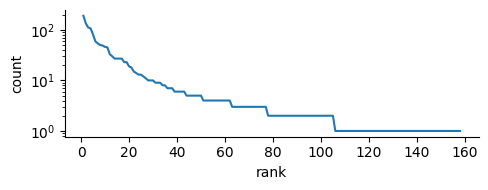

In [11]:
db.save_dataframe(
    virus_hits_count, table_name="viral_rank_plot",
    description="All virus OTUs ordered by their number of hits"
)

g = sns.relplot(
    data=virus_hits_count, y='count', x='rank', kind='line',
    height=2.0, aspect=2.5
)
# g.ax.axvline(10, linestyle='--', color='gray')
g.ax.set_yscale('log')


We can observe indeed a very heterogeneous distribution, with some hits exceeding the 100 detections. Let's see which could be these organisms.

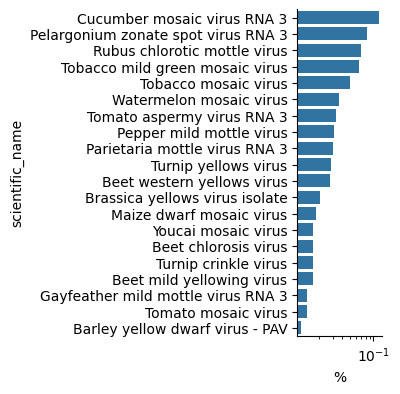

In [12]:
g = sns.catplot(
    data=virus_hits_count[:20], y='scientific_name', x='%', kind='bar', height=4.0, aspect=1.0
)
g.ax.set_xscale('log')

### How are the different PABs distributed?

We will generate a file that can be used as a table in the supplementary material, where bacteria are associated to their host ranges, PAB type, and number of hits. 

First, we will compute the host range, using the `host_taxon`, `taxid` and `scientific_name` as keys, and then counting by `scientific_name` and `taxid`. This should tell us how many different hosts can each entry find.  

In [13]:
virus_host_range = virus_hits.value_counts(
    ['host_taxon', 'scientific_name']
    ).reset_index().value_counts(
        ['scientific_name']
    ).reset_index().rename(columns={'count': 'host_range'})
# assert(len(virus_host_range) == 127) # INTRODUCING THIS KIND OF CHECKS CAN HELP US CHECKING OUR OPERATIONS
virus_host_range

,scientific_name,host_range
0,Cucumber mosaic virus RNA 3,83
1,Tobacco mild green mosaic virus,65
2,Pelargonium zonate spot virus RNA 3,58
3,Tobacco mosaic virus,52
4,Rubus chlorotic mottle virus,50
...,...,...
153,Potato leafroll virus,1
154,Petunia asteroid mosaic virus,1
155,Cucumber leaf spot virus,1
156,Pepper cryptic virus 2,1


Now, we will count the number of hits per habitat. To do so, we simply do a value counts of the hits sharing `taxid,scientific_name,habitat`, and then we pivot the dataset to get it columns.

In [14]:
virus_perhabitat = virus_hits.value_counts(["scientific_name", "habitat"]).reset_index() 
virus_perhabitat = virus_perhabitat.pivot(index=['scientific_name'], columns='habitat', values='count').fillna(0).reset_index()
virus_perhabitat


habitat,scientific_name,Crop,Edge,Oak,Wasteland
0,African eggplant yellowing virus,1.0,2.0,0.0,1.0
1,Ageratum latent virus RNA 1,0.0,1.0,0.0,0.0
2,Alfalfa enamovirus 1,0.0,0.0,1.0,0.0
3,Alfalfa mosaic virus RNA 2,0.0,0.0,1.0,2.0
4,Arabidopsis halleri partitivirus 1,0.0,0.0,1.0,0.0
...,...,...,...,...,...
153,Yam bean mosaic virus,3.0,0.0,0.0,0.0
154,Yam mosaic virus,3.0,0.0,0.0,1.0
155,Yam spherical virus,0.0,3.0,0.0,0.0
156,Youcai mosaic virus,1.0,5.0,9.0,12.0


A slightly more complex query consists on getting the host-ranges per habitat. To do so, we need to first deduplicate the bacteria-hit dataset by `scientific_name,taxid,host_taxon,habitat`, and then repeat. 

In [15]:
virus_hrperhabitat = virus_hits.drop_duplicates(
    ["scientific_name", "host_taxon", "habitat"]
).value_counts(
    ["scientific_name", "habitat"]
).reset_index() 
virus_hrperhabitat = virus_hrperhabitat.pivot(index=['scientific_name'], columns='habitat', values='count').fillna(0).reset_index()
virus_hrperhabitat


habitat,scientific_name,Crop,Edge,Oak,Wasteland
0,African eggplant yellowing virus,1.0,2.0,0.0,1.0
1,Ageratum latent virus RNA 1,0.0,1.0,0.0,0.0
2,Alfalfa enamovirus 1,0.0,0.0,1.0,0.0
3,Alfalfa mosaic virus RNA 2,0.0,0.0,1.0,2.0
4,Arabidopsis halleri partitivirus 1,0.0,0.0,1.0,0.0
...,...,...,...,...,...
153,Yam bean mosaic virus,1.0,0.0,0.0,0.0
154,Yam mosaic virus,1.0,0.0,0.0,1.0
155,Yam spherical virus,0.0,2.0,0.0,0.0
156,Youcai mosaic virus,1.0,5.0,9.0,12.0


Now, we will compute site-ranges: the number of different sites that are reached by each virus.

In [16]:
virus_sr = virus_hits.drop_duplicates(
    ["scientific_name", "site"]
).value_counts(
    ["scientific_name"]
).reset_index().rename(columns={'count': 'site_range'})
# bacteria_pab_sr = bacteria_pab_sr.pivot(index=['scientific_name', 'taxid', ], columns='site', values='count').fillna(0).reset_index()

virus_sr


,scientific_name,site_range
0,Cucumber mosaic virus RNA 3,21
1,Tobacco mild green mosaic virus,21
2,Rubus chlorotic mottle virus,19
3,Tobacco mosaic virus,18
4,Pelargonium zonate spot virus RNA 3,15
...,...,...
153,Potato virus Y,1
154,Potato necrosis virus,1
155,Potato leafroll virus,1
156,Petunia asteroid mosaic virus,1


Finally, we compute the number of habitats

In [17]:
virus_habitatr = virus_hits.drop_duplicates(
    ["scientific_name", "habitat"]
).value_counts(
    ["scientific_name"]
).reset_index().rename(columns={'count': 'habitat_range'})
# bacteria_pab_sr = bacteria_pab_sr.pivot(index=['scientific_name', 'taxid', ], columns='site', values='count').fillna(0).reset_index()
virus_habitatr


,scientific_name,habitat_range
0,Turnip crinkle virus,4
1,Plum pox virus,4
2,Tomato aspermy virus RNA 3,4
3,Tomato mosaic virus,4
4,Rubus chlorotic mottle virus,4
...,...,...
153,Pepper yellow dwarf virus,1
154,Pepper cryptic virus 2,1
155,Cotton leafroll dwarf virus,1
156,Cowpea aphid-borne mosaic virus,1


Now, we can try to merge it all.

In [18]:
virus_distribution = pd.merge(
    virus_hits.drop_duplicates(['scientific_name'])[['scientific_name', 'taxid']],
    virus_hits.value_counts(['scientific_name']).reset_index().rename(columns={'count': 'hits'})[['scientific_name', 'hits']],
    on=['scientific_name']
)

virus_distribution = pd.merge(
    virus_distribution,
    virus_habitatr,
    on=['scientific_name']
)

virus_distribution = pd.merge(
    virus_distribution,
    virus_host_range,
    on=['scientific_name']
)

virus_distribution = pd.merge(
    virus_distribution, virus_sr, on=['scientific_name']
)

virus_distribution = pd.merge(
    virus_distribution, virus_hrperhabitat.rename(columns={'Crop': 'Crop_HR', 'Edge': 'Edge_HR', 'Oak': 'Oak_HR', 'Wasteland': 'Wasteland_HR'}), 
    on=['scientific_name']
)

virus_distribution = pd.merge(
    virus_distribution, virus_perhabitat.rename(columns={'Crop': 'Crop_hits', 'Edge': 'Edge_hits', 'Oak': 'Oak_hits', 'Wasteland': 'Wasteland_hits'}), 
    on=['scientific_name']
)

virus_distribution

,scientific_name,taxid,hits,habitat_range,host_range,site_range,Crop_HR,Edge_HR,Oak_HR,Wasteland_HR,Crop_hits,Edge_hits,Oak_hits,Wasteland_hits
0,Barley yellow dwarf virus - GAV,224578,12,2,7,7,4.0,3.0,0.0,0.0,9.0,3.0,0.0,0.0
1,Barley yellow dwarf virus - PAS,2169985,13,3,7,9,4.0,2.0,0.0,1.0,10.0,2.0,0.0,1.0
2,Barley yellow dwarf virus - PAV,2169986,19,3,10,9,8.0,2.0,0.0,1.0,15.0,3.0,0.0,1.0
3,Cucumber mosaic virus RNA 3,12305,190,4,83,21,13.0,45.0,32.0,16.0,24.0,105.0,41.0,20.0
4,Rubus chlorotic mottle virus,378833,111,4,50,19,13.0,39.0,4.0,4.0,21.0,82.0,4.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
153,Alfalfa enamovirus 1,1770265,1,1,1,1,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
154,Pea enation mosaic virus 1,193121,1,1,1,1,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
155,Atractylodes mild mottle virus,1711685,1,1,1,1,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
156,Pepper cryptic virus 2,None,1,1,1,1,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


#### Testing

We have performed many operations at once. It is therefore convenient to check that the values that we are observing add up. Below, we will run a few tests.

In [19]:
# TEST 1: No organism should have a host range larger than the host range that we had measured 
# at one of the habitats. 
for i in range(len(virus_distribution)):
    example = virus_distribution.loc[i]
    try:
        assert(max([example.Crop_HR,example.Edge_HR, example.Oak_HR,example.Wasteland_HR]) <= example.host_range)
    except AssertionError: 
        print("{0} did not pass the test 1".format(example['scientific_name']))

In [20]:
for i in range(len(virus_distribution)):
    example = virus_distribution.loc[i]
    example_subset = virus_hits.query('scientific_name == "{0}"'.format(example.scientific_name))
    print(i)
    assert(len(example_subset) == int(example.Crop_hits + example.Edge_hits + example.Wasteland_hits + example.Oak_hits))
    assert(len(example_subset) == int(example.hits))
    assert(len(example_subset.drop_duplicates(['host_taxon'])) == example.host_range)
print("All tests passed! :-D")

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
All tests passed! :-D


#### Output

This table will be quite useful, so we will save it in a few different formats:

1. CSV to open it later.
2. Excel, to create a single multi-sheet document that eases the writing and the analysis by third parties.

In [21]:
db.save_dataframe(
    virus_distribution, table_name="D_VirusOTUs",
    description="This table summarizes most of the information of previously detected virus OTUs, including host_range, site_range, habitat_range, etc."
)
# virus_distribution.sort_values(by='scientific_name').to_csv("output/table.virus-distribution.csv", sep=";")
# with pd.ExcelWriter('output/MIRIPVIR25.xlsx') as writer:  
#     pab_distribution.sort_values(by='scientific_name').to_excel(writer, sheet_name='PAB-distribution')

Saved D_VirusOTUs to 2025-10-21


We could test these questions statistically, but in general if there is any effect, it seems weak. 

## Libraries

Again, simple Q & A

### What is the distribution of hits across our libraries?

To answer this question, first we need to value-count the number of total hits per library. We all save the habitat. 

In [22]:
# library_hits_count = bacteria_hits.value_counts(['library', 'site', 'habitat']).reset_index()
# library_hits_count['rank'] = np.arange(len(library_hits_count))
# library_hits_count

The following table indicates some values of the distribution.

In [23]:
# pd.DataFrame.from_records(
#     [
#         {"threshold": "=1", "count": len(library_hits_count.query('count == 1'))}, #88
#         {"threshold": ">1", "count": len(library_hits_count.query('count > 1'))}, #211
#         {"threshold": ">2", "count": len(library_hits_count.query('count > 2'))},
#         {"threshold": ">5", "count": len(library_hits_count.query('count > 5'))},
#         {"threshold": ">10", "count": len(library_hits_count.query('count > 10'))},
#     ]
# )



We have 299 positive libraries out of the 323 libraries, which means 24 negatives. Only 22 libraries have more than 10 OTUs detected.

We use the following rank plot to visualize the heterogeneity of host ranges.

In [24]:
# res_ = library_hits_count.sort_values(by='count', ascending=False).query('count > 0')
# res_['rank'] = np.arange(1, len(res_) + 1)

# db.save_dataframe(
#     res_, table_name="site_rank_plot",
#     description="Ranking of sites depending on their detections"
# )

# g = sns.relplot(
#     data=res_,
#     x='rank', y='count', kind='line',
#     height=2.0, aspect=2.0
# )
# g.ax.set_yscale('log')
# g.set_xlabels("rank")
# g.set_ylabels("# hits per library")

In [25]:
db.conn.close()